In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler



# data cleaning and feature engineering


In [ ]:
# data cleaning and feature engineering

df = pd.read_csv("Mall_Customers.csv")
df.sample(5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
119,120,Female,50,67,57
79,80,Female,49,54,42
28,29,Female,40,29,31
197,198,Male,32,126,74
0,1,Male,19,15,39


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.isna().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df.select_dtypes(include=[object])


,Gender
0,Male
1,Male
2,Female
3,Female
4,Female
...,...
195,Female
196,Female
197,Male
198,Male


In [ ]:
df.select_dtypes(include='float')

""
0
1
2
3
4
...
195
196
197
198


In [ ]:
df.drop(columns=['CustomerID', 'Gender'], inplace=True)
df.sample(5)

,Age,Annual Income (k$),Spending Score (1-100)
164,50,85,26
41,24,38,92
131,39,71,75
71,47,49,42
115,19,65,50


In [ ]:
corr= df.corr()
print(corr)

                             Age  Annual Income (k$)  Spending Score (1-100)
Age                     1.000000           -0.012398               -0.327227
Annual Income (k$)     -0.012398            1.000000                0.009903
Spending Score (1-100) -0.327227            0.009903                1.000000


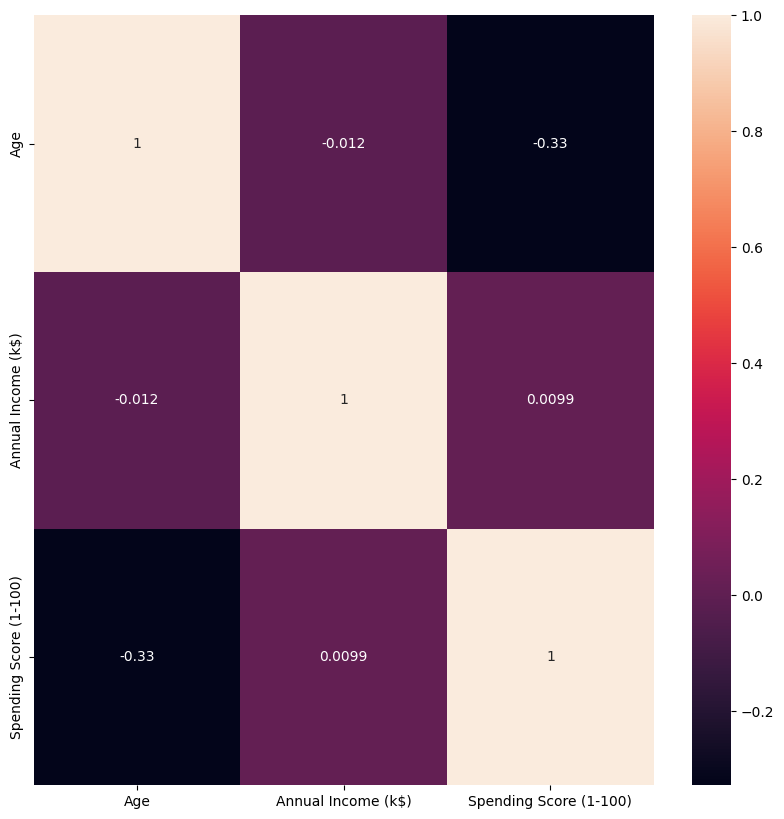

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,10))

sns.heatmap(corr,annot=True)
plt.show()

Removing outliers

In [ ]:
for columns in ['Annual Income (k$)', 'Spending Score (1-100)']:

  Q1 =np.percentile(df[columns], 25)
  Q3 = np.percentile(df[columns],75)

  IQR=Q3-Q1

  lower_bound= Q1- 1.5*IQR
  upper_bound= Q3 +1.5*IQR

  df = df[(df[columns]>= lower_bound) & ( df[columns] <= upper_bound)]
  X=df.values

In [ ]:
print(X[:5])

[[19 15 39]
 [21 15 81]
 [20 16  6]
 [23 16 77]
 [31 17 40]]


normalization

In [ ]:
scalar=MinMaxScaler()
X_scaled=scalar.fit_transform(X)
print(X_scaled[:10])

[[0.01923077 0.         0.3877551 ]
 [0.05769231 0.         0.81632653]
 [0.03846154 0.00900901 0.05102041]
 [0.09615385 0.00900901 0.7755102 ]
 [0.25       0.01801802 0.39795918]
 [0.07692308 0.01801802 0.76530612]
 [0.32692308 0.02702703 0.05102041]
 [0.09615385 0.02702703 0.94897959]
 [0.88461538 0.03603604 0.02040816]
 [0.23076923 0.03603604 0.7244898 ]]


K_mean from scratch

In [ ]:
class KMeanFromScratch:
  def __init__ ( self ,  k=5, max_iter=100 , random_state=33):
    self.k=k
    self.max_iter = max_iter
    self.random_state=random_state
    self.centroid =None

  def fit(self , X):
    np.random.seed(self.random_state)

    random_indices= np.random.choice(X.shape[0],self.k , replace =False)
    self.centroid=X[random_indices]

    for itetration in range (self.max_iter):
      labels=self.assign_label(X)

      old_centroids = self.centroid.copy()


      for idx in range ( self.k):
        cluster_points= X[labels == idx]

        if len(cluster_points) >0:
          self.centroid[idx]=np.mean(cluster_points , axis =0)

      if np.all(old_centroids == self.centroid):
        print(f"convergence early at itetration {itetration}")
        break

    return labels, self.centroid





  def assign_label(self,X):

    labels=[]
    for point in X:

      distance=np.sqrt(np.sum((self.centroid - point)**2 , axis =1))

      closest_centroid_idx=np.argmin(distance)
      labels.append(closest_centroid_idx)

    return np.array(labels)

Execution

In [ ]:
kmeans= KMeanFromScratch(k=5)
cluster_assignment , final_centroid = kmeans.fit(X_scaled)


print(f"assigned cluster count :{np.bincount(cluster_assignment)}")
print(f"final centroid :{final_centroid}")

convergence early at itetration 6
assigned cluster count :[22 59 39 46 32]
final centroid :[[0.13986014 0.0966421  0.79962894]
 [0.72327249 0.30508475 0.41075752]
 [0.28747535 0.62878263 0.82129775]
 [0.18645485 0.3115942  0.44232476]
 [0.44230769 0.65343468 0.16230867]]


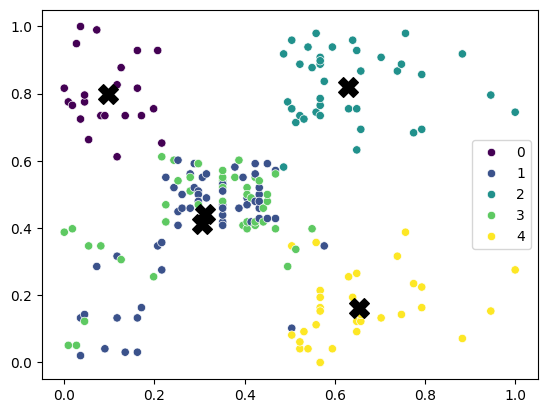

In [ ]:
sns.scatterplot(x=X_scaled[:, 1], y=X_scaled[:, 2], hue=cluster_assignment, palette="viridis")

# 2. Plot the final centroids as big black dots (using column 1 for Income, 2 for Spending)
plt.scatter(final_centroid[:, 1], final_centroid[:, 2], c="black", s=200, marker="X", label="Centroids")

plt.show()

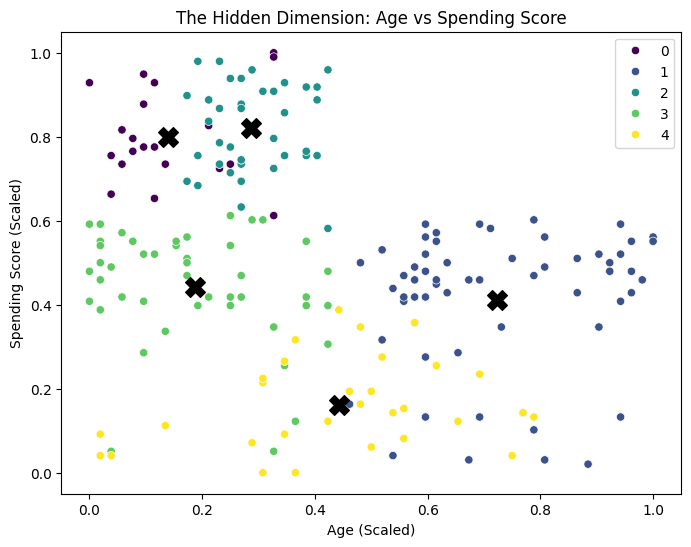

In [ ]:


plt.figure(figsize=(8, 6))

# Plot Age (column 0) vs Spending Score (column 2)
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 2], hue=cluster_assignment, palette="viridis")

# Plot the centroids for Age vs Spending Score
plt.scatter(final_centroid[:, 0], final_centroid[:, 2], c="black", s=200, marker="X", label="Centroids")

plt.xlabel("Age (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.title("The Hidden Dimension: Age vs Spending Score")
plt.show()